##Scrapping Google Apps Review - H&M - Thailand & Indonesia
Mirza Fathi Taufiqurrahman 5026231105

Homework: WEEK 3/ 11 maret 2026 (TUGAS 1)

Re-run google colab ini, dengan dataset apps review masing2.
Berikan analisa sederhana, dan upload di github.


In [28]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

In [29]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [47]:
from google_play_scraper import app, Sort, reviews_all

hnm_reviews = reviews_all(
    'com.hm.gillcaptital',
    sleep_milliseconds=0, # defaults to 0
    lang='id',
    sort=Sort.NEWEST,
)

In [48]:
from google_play_scraper import Sort, reviews_all
import pandas as pd
#Save reviews into dataframe
df_hnm = pd.DataFrame(np.array(hnm_reviews),columns=['content'])
df_hnm = df_hnm.join(pd.DataFrame(df_hnm.pop('content').tolist()))
df_hnm.to_csv(r'df_hnm', index=False)

In [49]:
df_hnm

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f1d93333-d030-40c7-a595-d9e3363805d7,Vanda Selabica,https://play-lh.googleusercontent.com/a-/ALV-UjWkQvRemVfkhhxjbK7lScxC0m3RGTbF7Ha-ny_6dJyDHwZRNO49,apk lemot bgt buset,1,0,21.3.5-PROD,2026-03-05 01:07:34,None,None,21.3.5-PROD
1,01d442aa-cae2-4ace-98d7-1a493d1f4309,Rizqi Alkhairi,https://play-lh.googleusercontent.com/a/ACg8ocJvxVsAgKVtNTa375vTgONlFP8tAZvMMjLv5Af6Ptjw1Os--g=mo,lu mau internet sekencang apa?,1,0,21.3.5-PROD,2026-03-04 14:48:04,None,None,21.3.5-PROD
2,e1ab8869-4a60-4965-8f6f-a04337fd3a65,Muhammad Amin,https://play-lh.googleusercontent.com/a/ACg8ocIsj2aVjntNxsBoyKFNQ95qtLFzC7vZTPoG9oidkzbp0yjerg=mo,"barangnya pas dihati , harga nya pas di dompet",5,1,21.2.1-PROD,2026-03-04 10:24:31,None,None,21.2.1-PROD
3,29d6a939-319a-444a-a5a4-e90e60149f19,nzw Ghrsy,https://play-lh.googleusercontent.com/a/ACg8ocL-7UuJCVPNfftD_08IuCloohpyrhDGuYxEBPinEV1cay7nuyDy=mo,"kenapa susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk ini biar bisa beli online gausa jauh, tp malah susah",3,0,21.3.1-PROD,2026-02-10 03:57:38,None,None,21.3.1-PROD
4,1e77f36f-136c-469d-9a52-fa1a9ab7ecbf,dewi generali,https://play-lh.googleusercontent.com/a-/ALV-UjUHEMxtFTa4rzgsjBGHwK_CPDpQDsETGx3vJLkEiZ42v7TFg1-S,mantap..,5,0,None,2026-02-07 04:46:36,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...
2025,950bac2e-c7ff-46dc-a4e0-2c5c73326d55,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Lemod dan tergembel gabisa di akses setelahh di download!!!,1,10,0.0.3,2019-11-19 13:53:37,None,None,0.0.3
2026,5c9e9514-17f7-4ff0-a7c7-c75755f212df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Lemot bgt parahh,3,10,0.0.3,2019-10-04 21:17:57,None,None,0.0.3
2027,c7167f12-f406-4f71-b872-4bf2bc44893f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Kok gabisa cek orderan ya?,2,46,0.0.3,2019-09-26 11:44:17,None,None,0.0.3
2028,62a5547d-b0e5-4873-b0b9-1fb6928856ab,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Mantap,5,6,None,2019-09-25 16:39:19,None,None,None


In [50]:
df_hnm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2030 non-null   object        
 1   userName              2030 non-null   object        
 2   userImage             2030 non-null   object        
 3   content               2030 non-null   object        
 4   score                 2030 non-null   int64         
 5   thumbsUpCount         2030 non-null   int64         
 6   reviewCreatedVersion  1788 non-null   object        
 7   at                    2030 non-null   datetime64[ns]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            1788 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 174.6+ KB


In [51]:
df_analysis = df_hnm.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

In [52]:
#Check number of reviews scores
df_hnm['score'].value_counts()

,count
score,
1,759
5,689
3,219
2,203
4,160


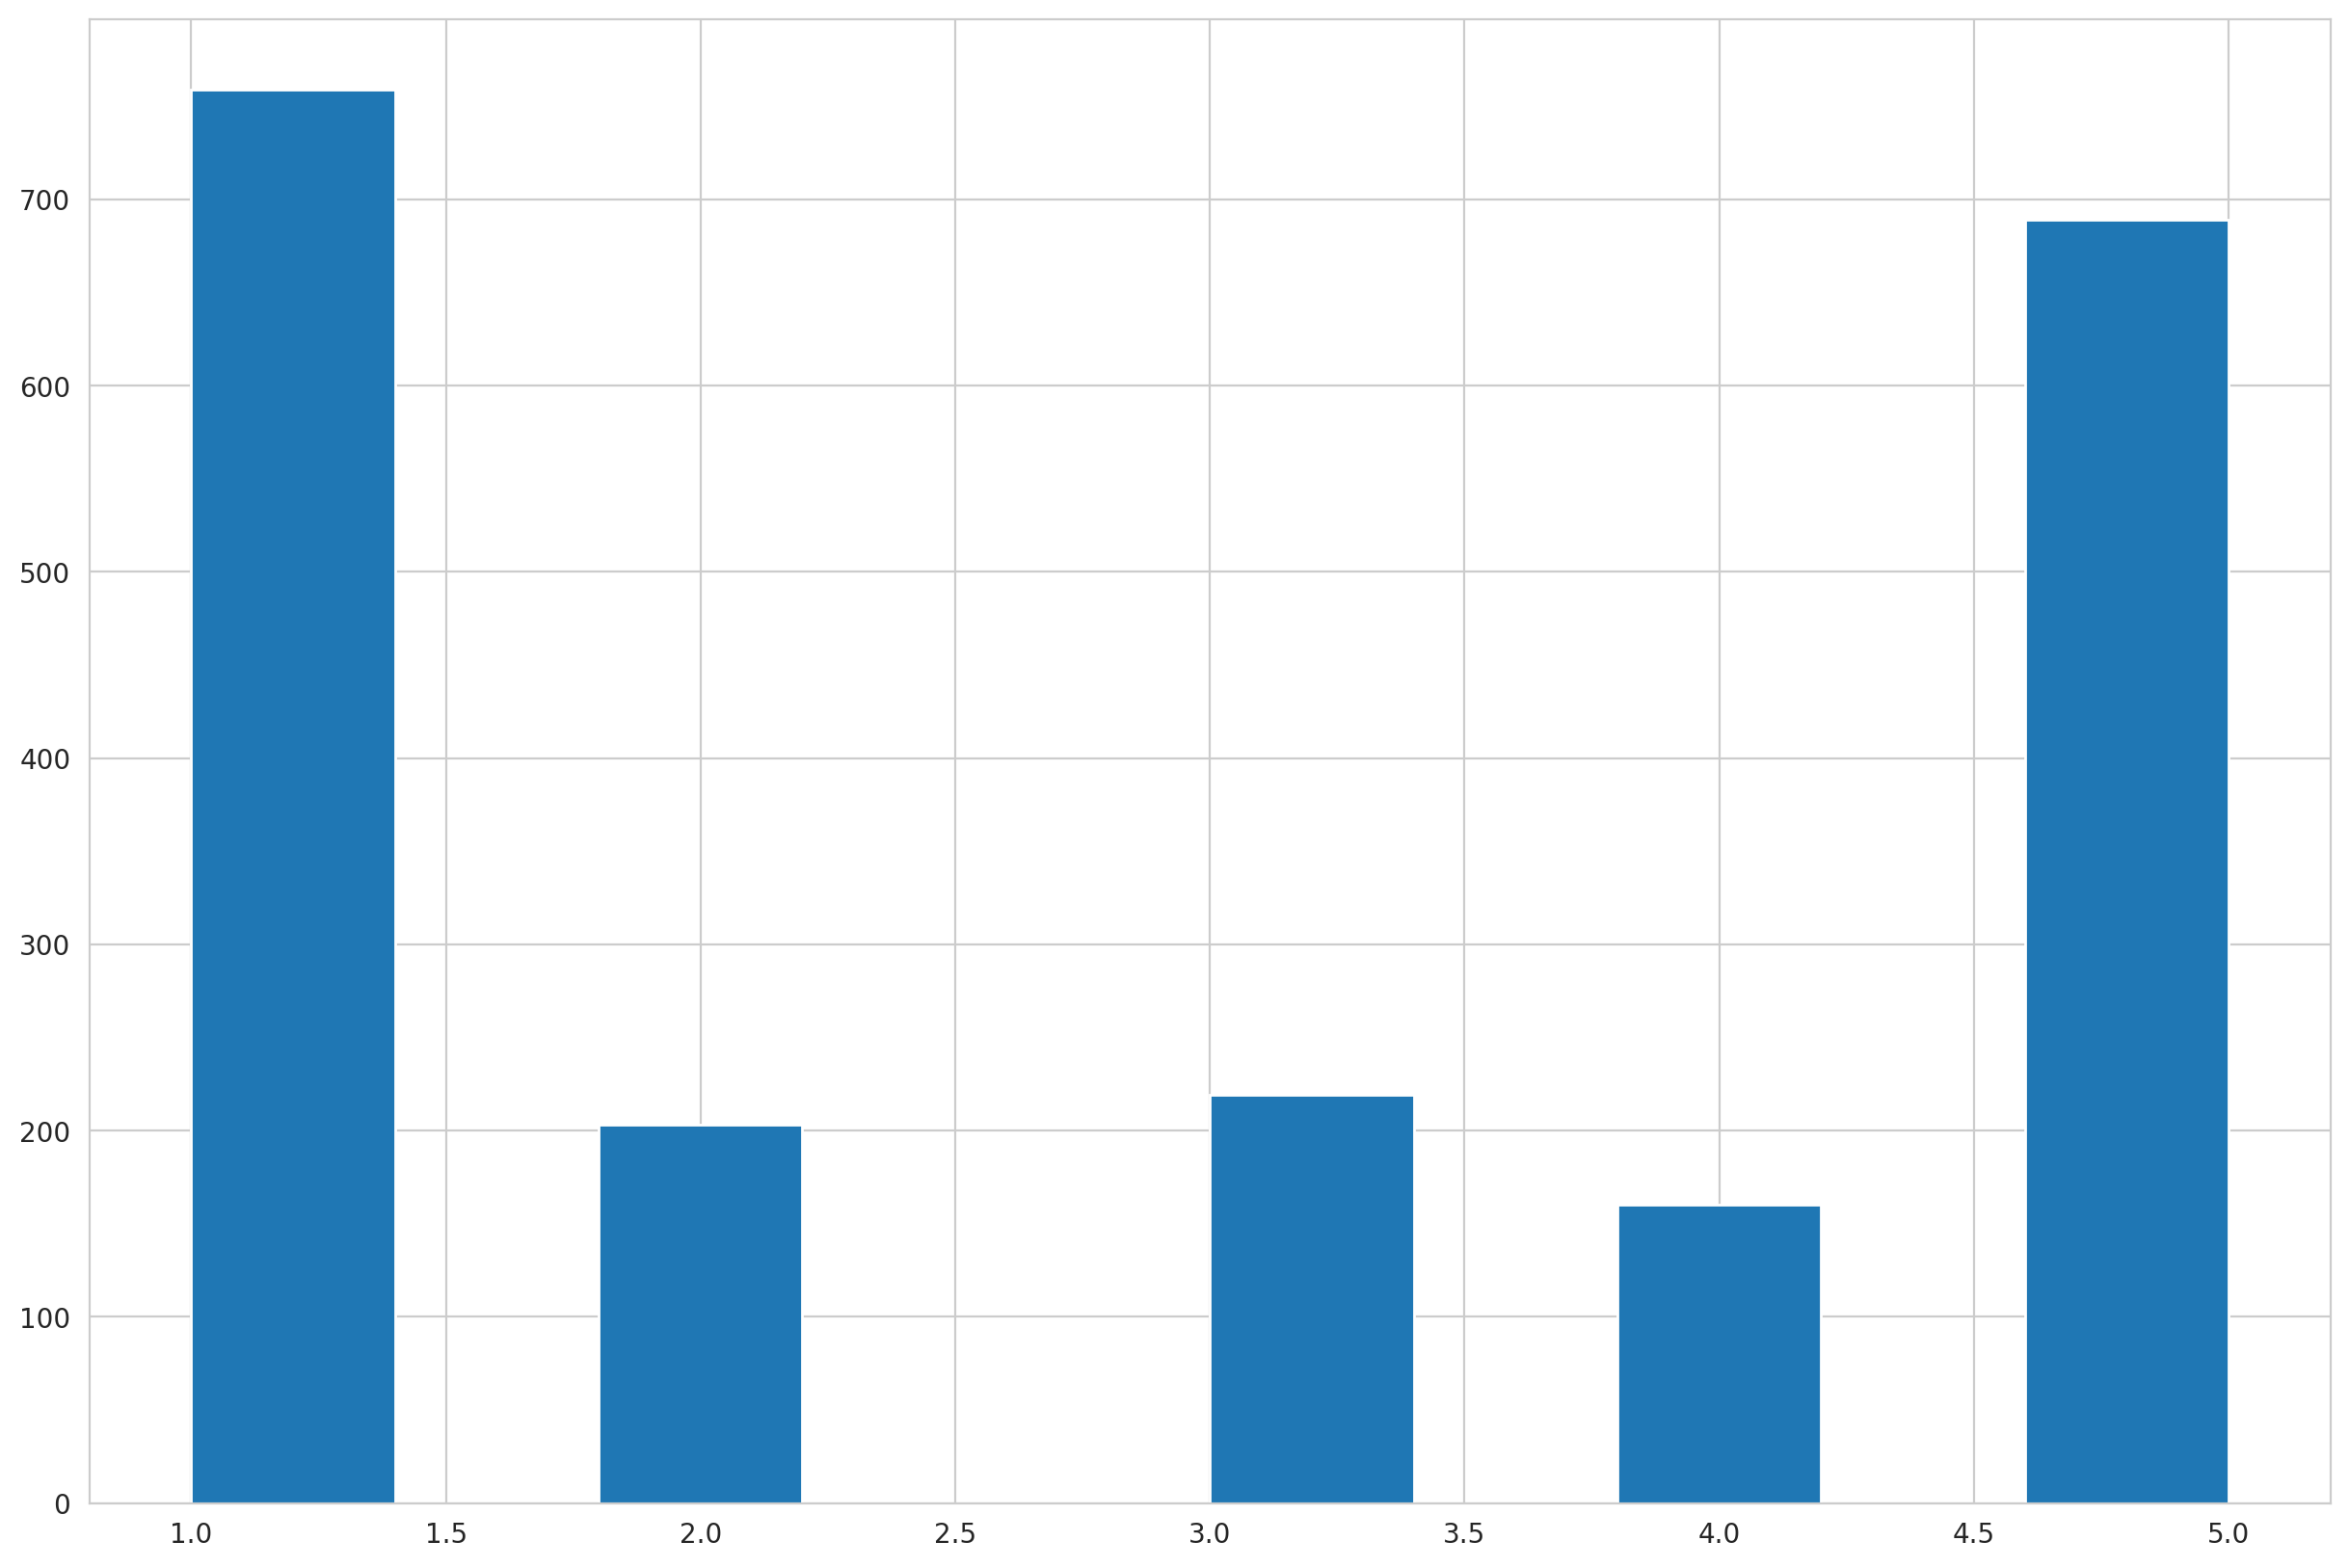

In [53]:
plt.hist(df_hnm['score'])
plt.show()

In [54]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

In [59]:
# Works for English
from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_hnm['sentiment_polarity'] = df_hnm['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_hnm['sentiment_subjective'] = df_hnm['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)


In [60]:
df_hnm.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,apk lemot bgt buset,1,0.0,0.0
1,lu mau internet sekencang apa?,1,0.0,0.0
2,"barangnya pas dihati , harga nya pas di dompet",5,0.0,0.0
3,"kenapa susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk ini biar bisa beli online gausa jauh, tp malah susah",3,0.0,0.0
4,mantap..,5,0.0,0.0
...,...,...,...,...
2025,Lemod dan tergembel gabisa di akses setelahh di download!!!,1,0.0,0.0
2026,Lemot bgt parahh,3,0.0,0.0
2027,Kok gabisa cek orderan ya?,2,0.0,0.0
2028,Mantap,5,0.0,0.0


### Indonesian Sentiment Analysis: Lexicon-Based Approach

Since `TextBlob` is not suitable for Indonesian, i tried to create a simple lexicon-based sentiment analyzer

In [61]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.data.find('tokenizers/punkt')

indonesian_positive_words = set([
    "bagus", "baik", "suka", "mantap", "puas", "sempurna", "hebat", "ok", "oke",
    "mudah", "cepat", "nyaman", "ramah", "rekomendasi", "canggih", "berhasil",
    "memuaskan", "luar biasa", "terbaik", "bagus sekali", "sangat baik",
    "bermanfaat", "inovatif", "efisien", "akurasi", "tepat", "membantu", "penyelamat"
])

indonesian_negative_words = set([
    "buruk", "lemot", "jelek", "sulit", "susah", "gagal", "error", "masalah", "bug", "lambat",
    "parah", "mengecewakan", "kecewa", "payah", "rusak", "tidak bisa", "berhenti",
    "crash", "bingung", "membingungkan", "rumit", "kurang", "tidak", "buruk sekali",
    "sangat buruk", "tidak bagus", "lelet", "membebani", "tidak berfungsi", "tidak responsif"
])

def analyze_indonesian_sentiment_lexicon(text):
    text = str(text).lower()
    words = word_tokenize(text)

    positive_count = sum(1 for word in words if word in indonesian_positive_words)
    negative_count = sum(1 for word in words if word in indonesian_negative_words)

    if positive_count > negative_count:
        return 'Positive'
    elif negative_count > positive_count:
        return 'Negative'
    else:
        return 'Neutral'


df_hnm['indonesian_sentiment_lexicon'] = df_hnm['content'].apply(analyze_indonesian_sentiment_lexicon)

print("Indonesian Sentiment Analysis using Lexicon-Based Approach:")
display(df_hnm[['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'indonesian_sentiment_lexicon']].head(10))

print("\nDistribution of Indonesian Lexicon Sentiment:")
display(df_hnm['indonesian_sentiment_lexicon'].value_counts())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Indonesian Sentiment Analysis using Lexicon-Based Approach:


,content,score,sentiment_polarity,sentiment_subjective,indonesian_sentiment_lexicon
0,apk lemot bgt buset,1,0.0,0.0,Negative
1,lu mau internet sekencang apa?,1,0.0,0.0,Neutral
2,"barangnya pas dihati , harga nya pas di dompet",5,0.0,0.0,Neutral
3,"kenapa susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk ini biar bisa beli online gausa jauh, tp malah susah",3,0.0,0.0,Negative
4,mantap..,5,0.0,0.0,Positive
5,"puas banget belanja disini, pengembalian mudah, sering diskon jg mantep",5,0.0,0.0,Positive
6,"pengiriman lama bgt, sudah 6 hari paket belum sampai2, gak jelas dan gak profesional sama sekali",1,0.0,0.0,Neutral
7,sudah order dan jadi member pas login pake akun yg sama malah gak bisa,1,0.0,0.0,Neutral
8,Gak bisa belanja online langsung dari aplikasinya,5,0.0,0.0,Neutral
9,aplikasi rusak,1,0.0,0.0,Negative



Distribution of Indonesian Lexicon Sentiment:


,count
indonesian_sentiment_lexicon,
Neutral,1104
Negative,562
Positive,364


## Lowercasing

In [62]:
#DATA PREPROCESSING
# Lower casing
# Change the reviews type to string
df_hnm['content'] = df_hnm['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_hnm['content'][188])
print(df_hnm['content'][1])
print(df_hnm['content'][201])

Kenapa susah sekali untuk buka apliaksi ny.. Tidak merespons terus
lu mau internet sekencang apa?
Ga ngerti lg ini ngelag mulu :(


In [63]:
#Lowercase all reviews to see the difference
df_hnm['content']= df_hnm['content'].apply(lambda x: x.lower())
print(df_hnm['content'][188])
print(df_hnm['content'][1])
print(df_hnm['content'][201])

kenapa susah sekali untuk buka apliaksi ny.. tidak merespons terus
lu mau internet sekencang apa?
ga ngerti lg ini ngelag mulu :(


##Stopwords Removal
Indonesian Stopwords

In [64]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [66]:
import string

df_hnm['wordCount'] = [len(review.split()) for review in df_hnm['content']]
df_hnm['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_hnm['content']]
df_hnm['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_hnm['content']]

In [67]:
df_hnm.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,apk lemot bgt buset,1,0.0,0.0,4,0,0
1,lu mau internet sekencang apa?,1,0.0,0.0,5,0,1
2,"barangnya pas dihati , harga nya pas di dompet",5,0.0,0.0,9,0,1
3,"kenapa susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk ini biar bisa beli online gausa jauh, tp malah susah",3,0.0,0.0,29,0,3
4,mantap..,5,0.0,0.0,1,0,2
...,...,...,...,...,...,...,...
2025,lemod dan tergembel gabisa di akses setelahh di download!!!,1,0.0,0.0,9,0,3
2026,lemot bgt parahh,3,0.0,0.0,3,0,0
2027,kok gabisa cek orderan ya?,2,0.0,0.0,5,0,1
2028,mantap,5,0.0,0.0,1,0,0


In [68]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_hnm['sentiment_rating'] = df_hnm['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [69]:
df_hnm.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,apk lemot bgt buset,1,0.0,0.0,Negative
1,lu mau internet sekencang apa?,1,0.0,0.0,Negative
2,"barangnya pas dihati , harga nya pas di dompet",5,0.0,0.0,Positive
3,"kenapa susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk ini biar bisa beli online gausa jauh, tp malah susah",3,0.0,0.0,Neutral
4,mantap..,5,0.0,0.0,Positive
...,...,...,...,...,...
2025,lemod dan tergembel gabisa di akses setelahh di download!!!,1,0.0,0.0,Negative
2026,lemot bgt parahh,3,0.0,0.0,Neutral
2027,kok gabisa cek orderan ya?,2,0.0,0.0,Negative
2028,mantap,5,0.0,0.0,Positive


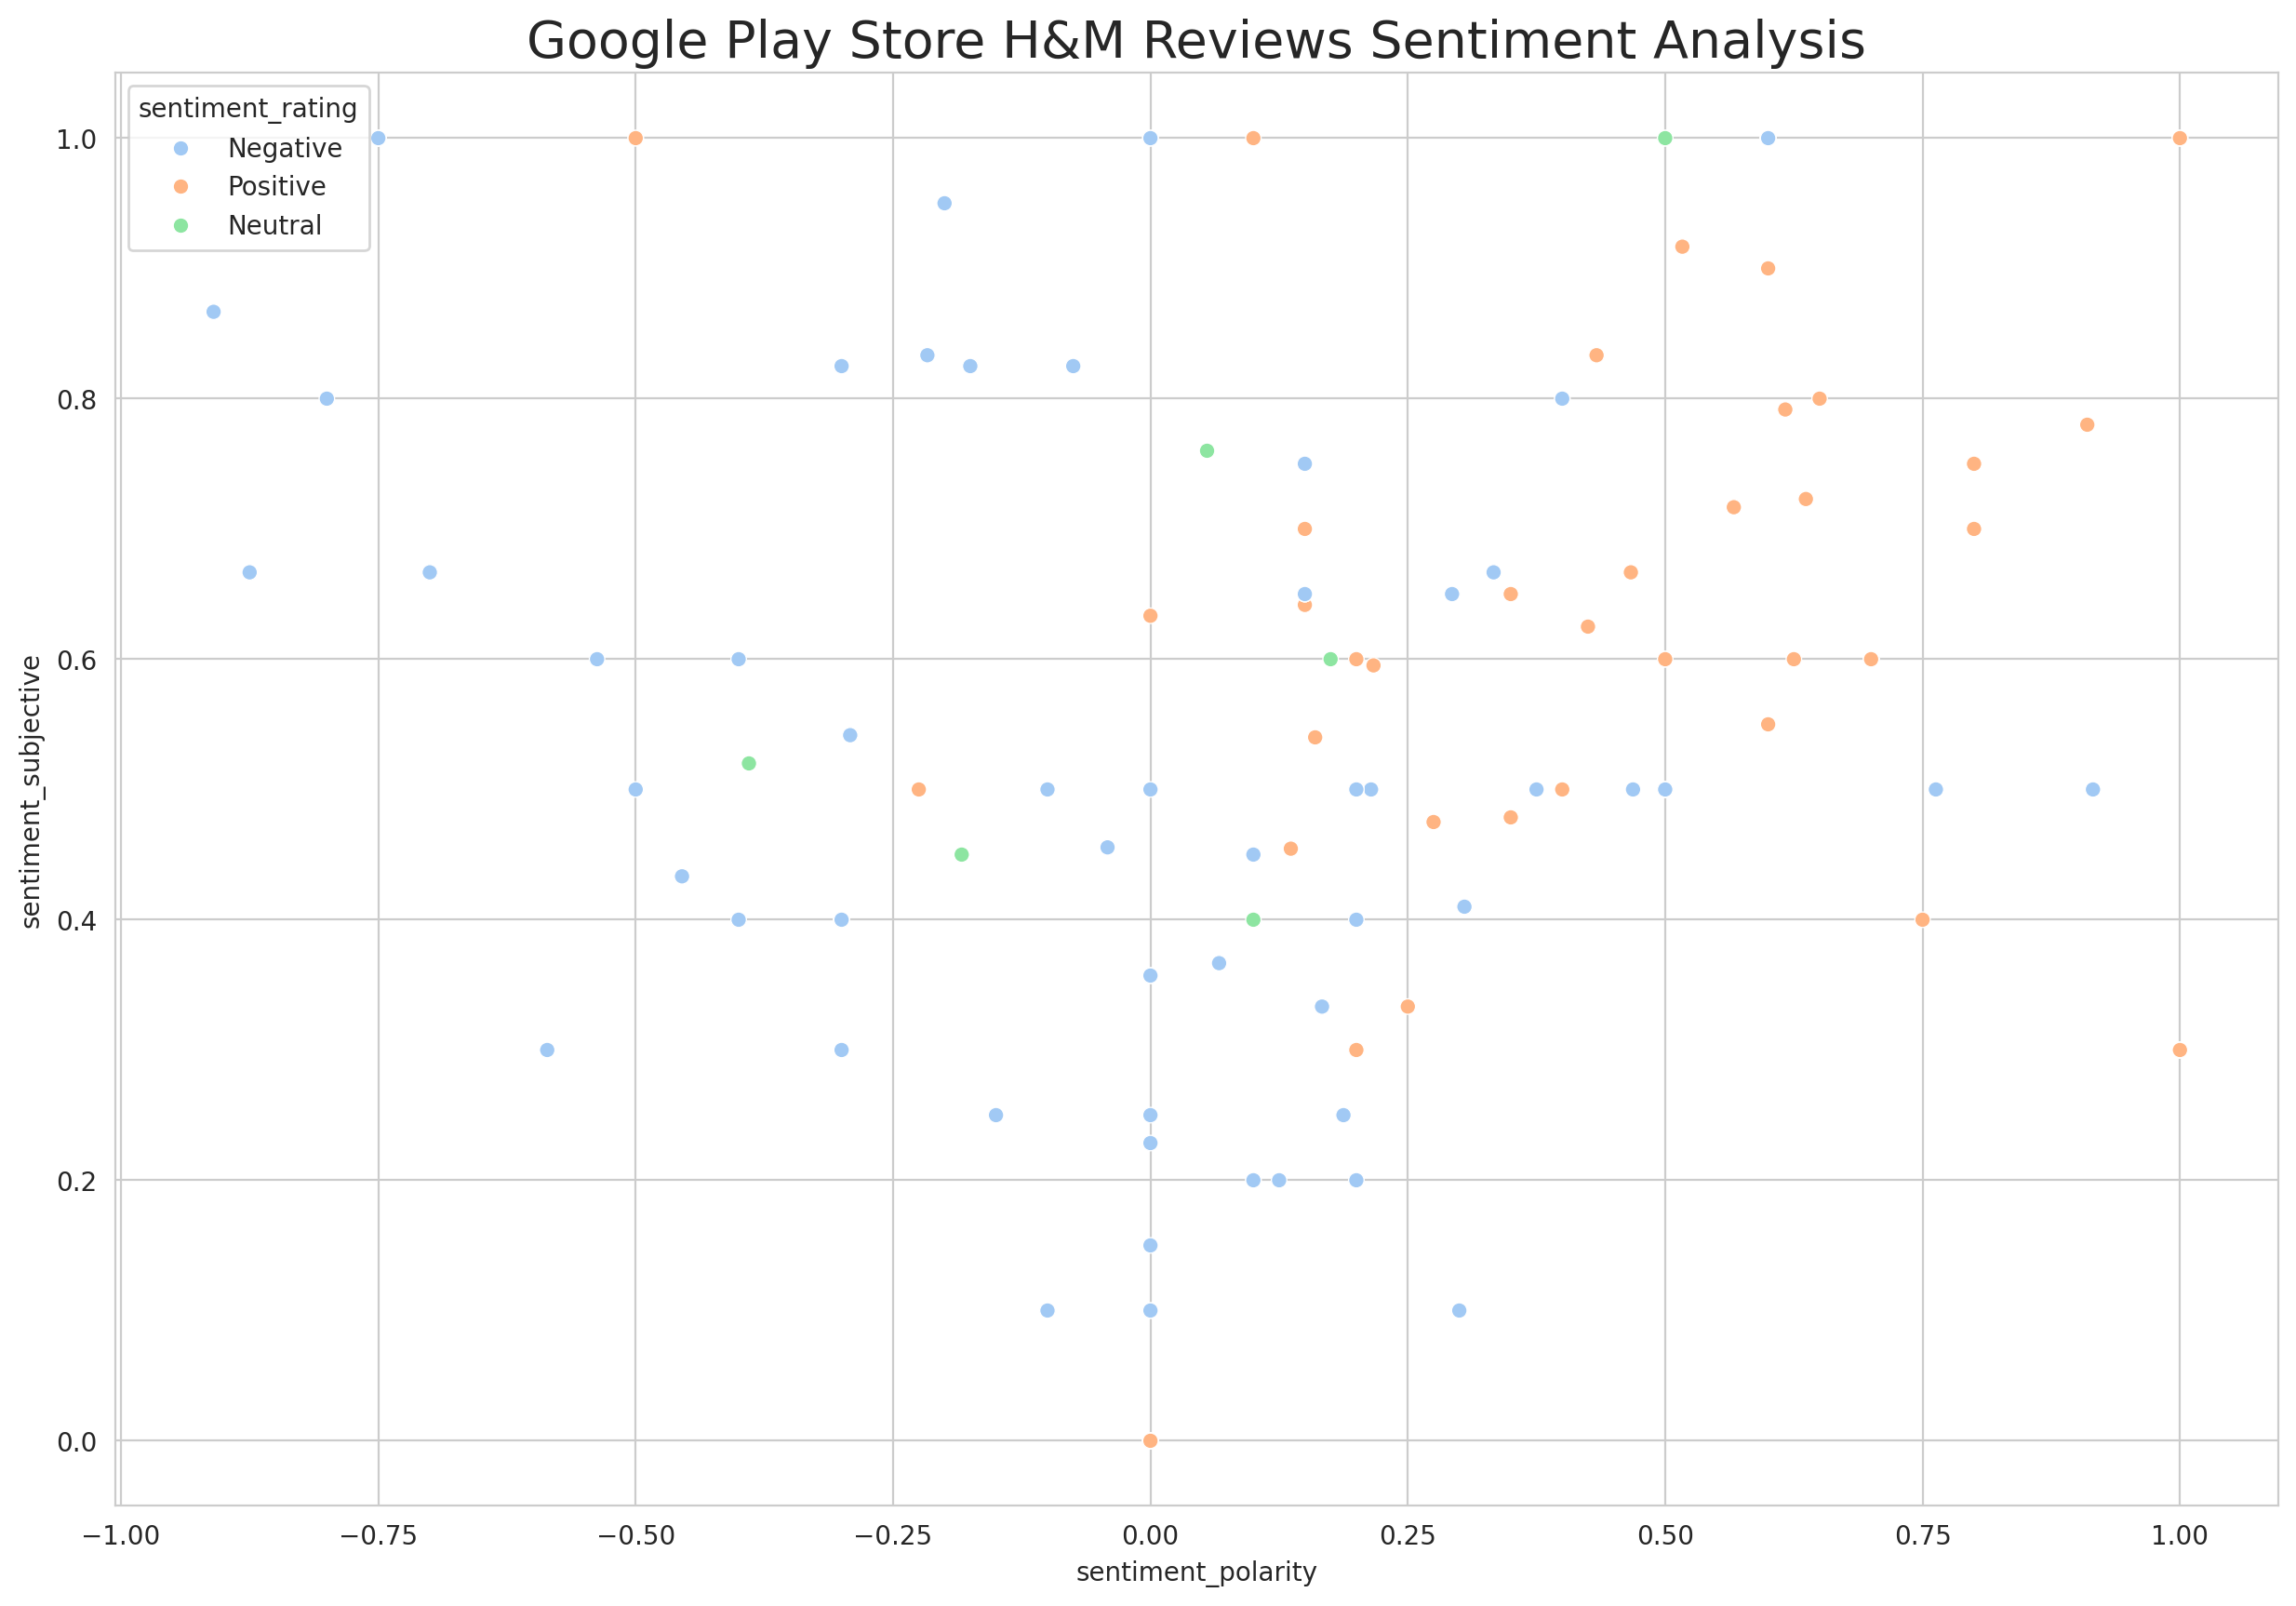

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_hnm['sentiment_polarity'], y=df_hnm['sentiment_subjective'],
                hue=df_hnm['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store H&M Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [74]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_193/2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


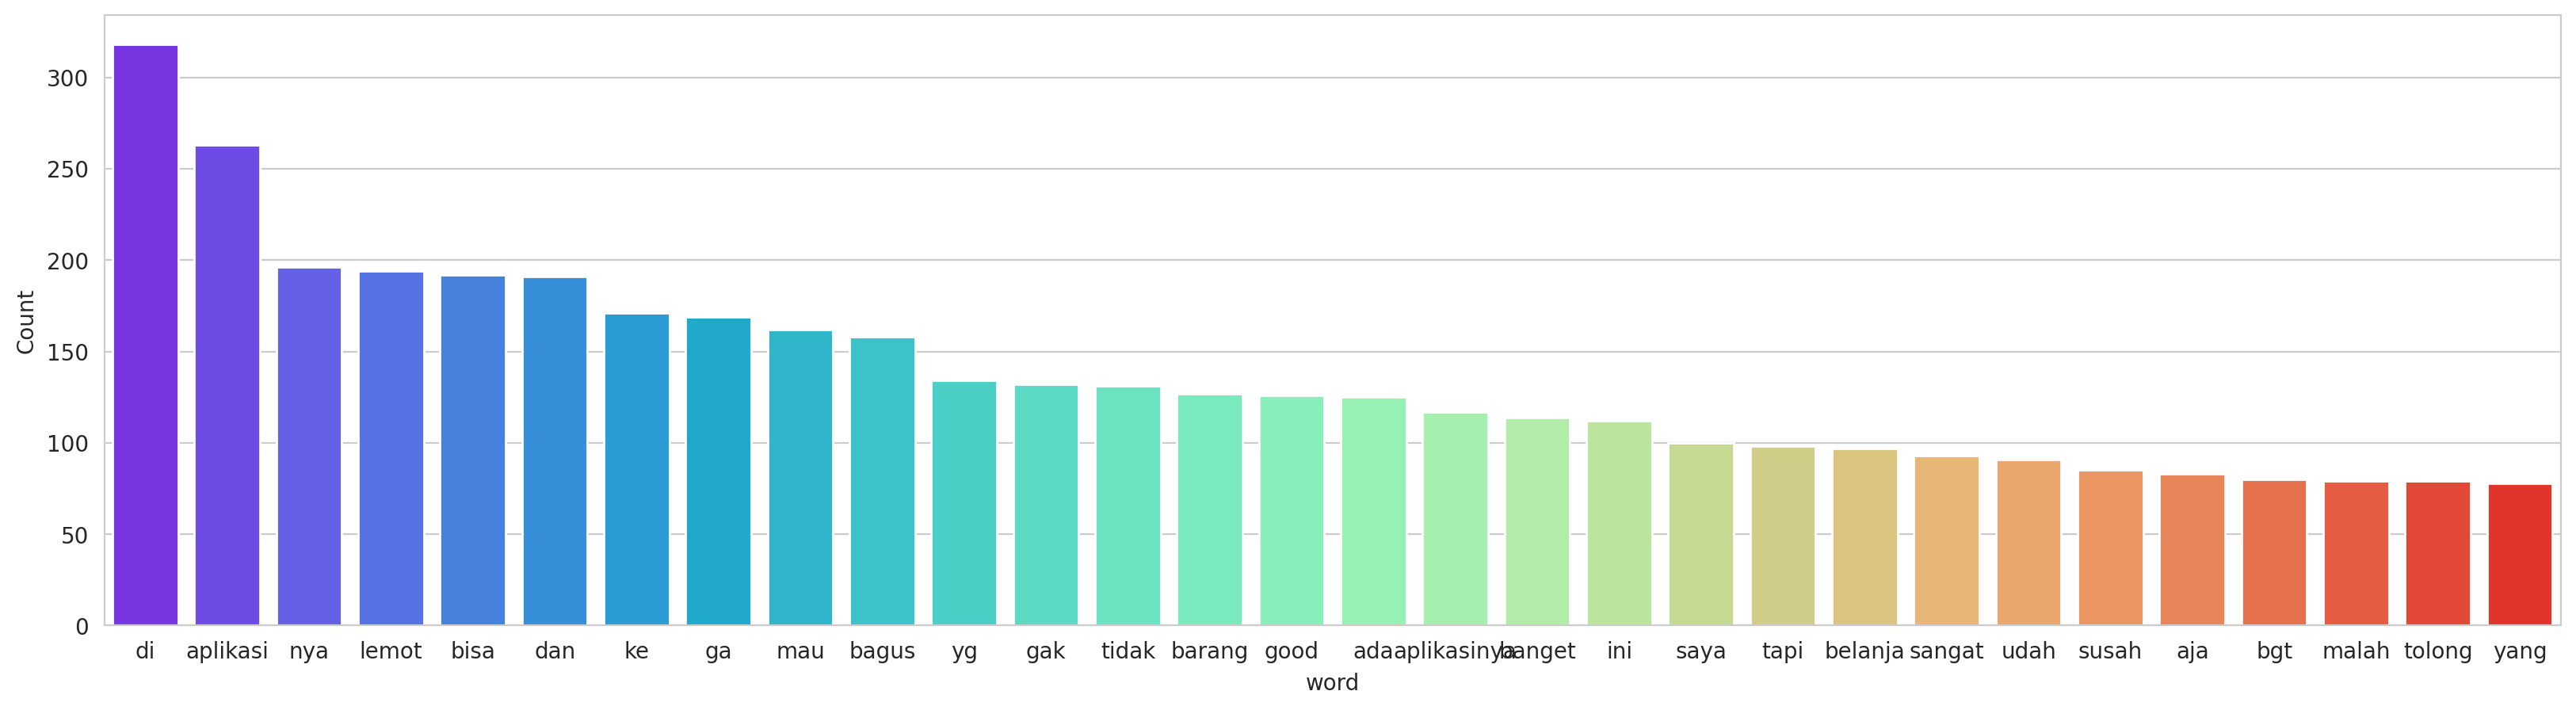

In [75]:
freq_words(df_hnm['content'])

In [76]:
!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Create stopword remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Apply stopword removal to the 'content' column
df_hnm['content'] = df_hnm['content'].apply(lambda x: stopword_remover.remove(x))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.2 MB/s eta 0:00:00


In [77]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get English stopwords
english_stopwords = stopwords.words('english')

# Assuming df_jknrev is your DataFrame and 'content' is the column
df_hnm['content'] = df_hnm['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in english_stopwords]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [88]:
english_stopwords(len)

198


In [79]:
df_hnm.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,apk lemot bgt buset,1,0.0,0.0,Negative
1,lu mau internet sekencang apa?,1,0.0,0.0,Negative
2,"barangnya pas dihati , harga nya pas dompet",5,0.0,0.0,Positive
3,"susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk biar beli online gausa jauh, tp malah susah",3,0.0,0.0,Neutral
4,mantap..,5,0.0,0.0,Positive
...,...,...,...,...,...
2025,lemod tergembel gabisa akses setelahh download!!!,1,0.0,0.0,Negative
2026,lemot bgt parahh,3,0.0,0.0,Neutral
2027,kok gabisa cek orderan ya?,2,0.0,0.0,Negative
2028,mantap,5,0.0,0.0,Positive


In [80]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_193/2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


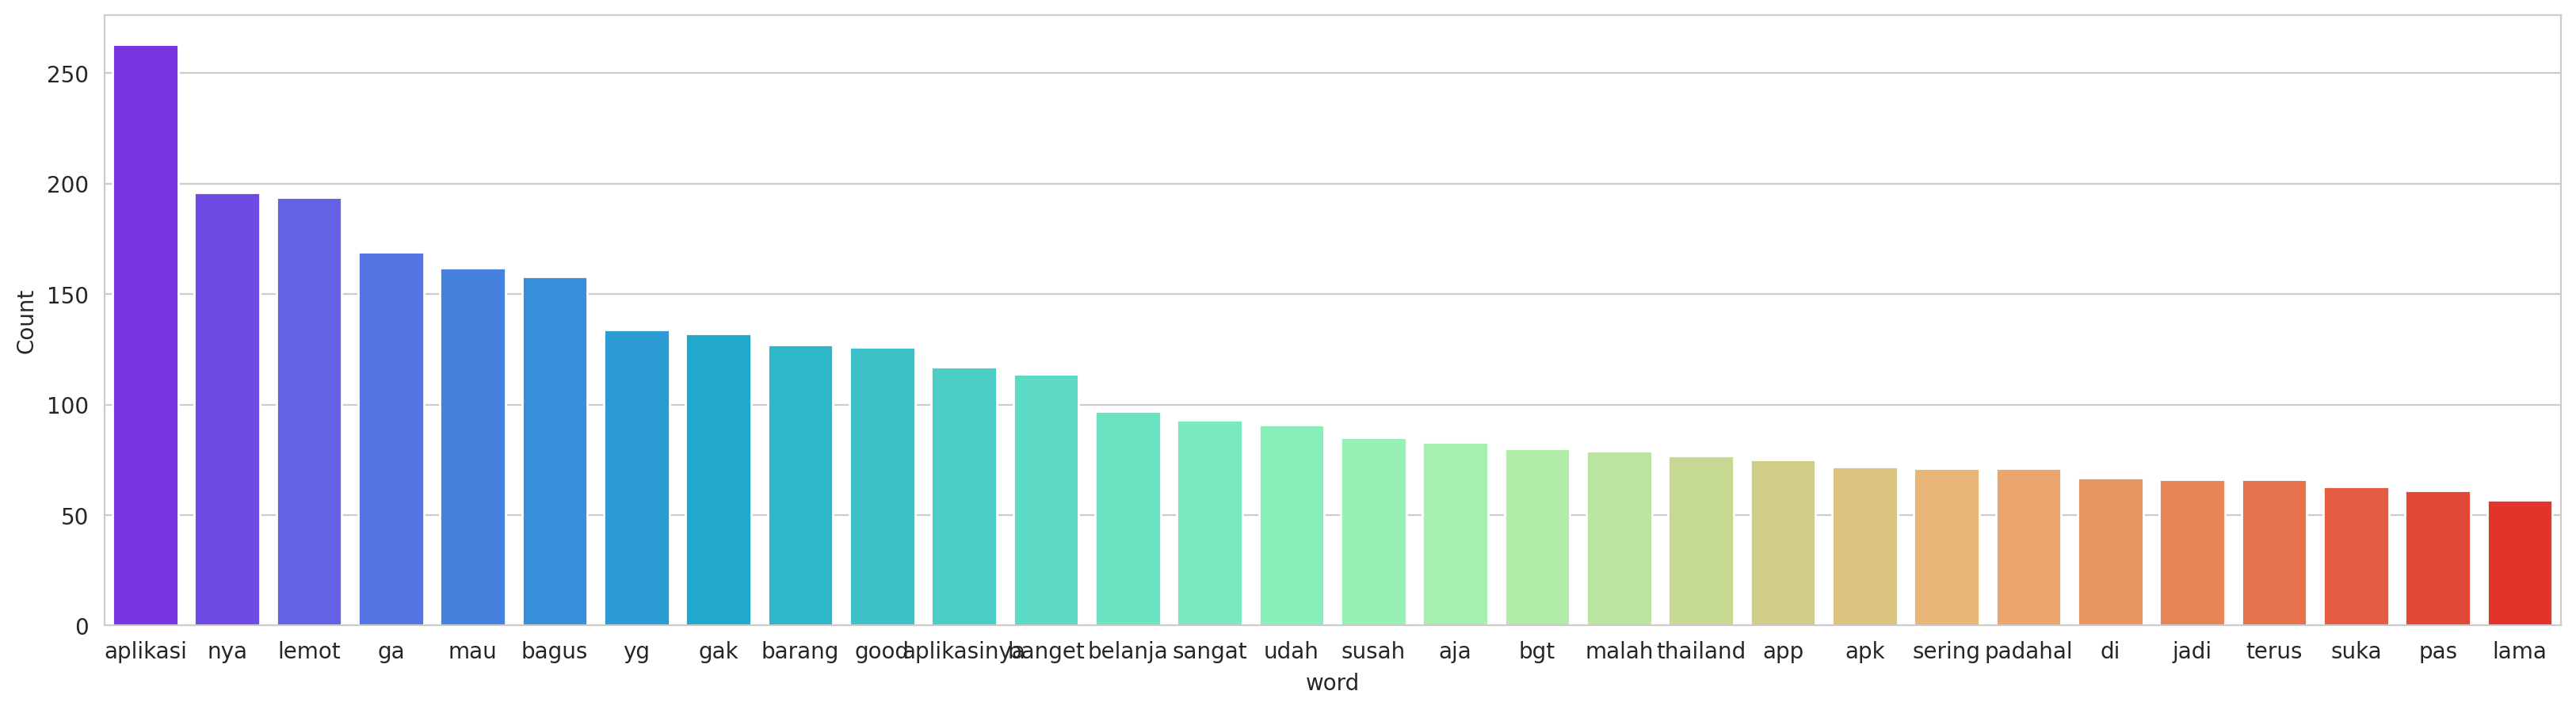

In [87]:
freq_words(df_hnm['content'])

In [86]:
#Count after stopwords
import string

# The stopword removal was applied directly to df_hnm['content']
# So, calculate word counts based on the updated df_hnm['content']
df_hnm['wordCount_after_stopwords'] = [len(review.split()) for review in df_hnm['content']]


In [89]:
display(df_hnm[['content', 'wordCount', 'wordCount_after_stopwords']].head())

,content,wordCount,wordCount_after_stopwords
0,apk lemot bgt buset,4,4
1,lu mau internet sekencang apa?,5,5
2,"barangnya pas dihati , harga nya pas dompet",9,8
3,"susah mau mau isi tanggal lahir juga, angka selalu ga sesuai katanya ga jelas. pdhl sengaja pake apk biar beli online gausa jauh, tp malah susah",29,26
4,mantap..,1,1


# Simple Analysis dari Preprocessing
Titik-titik tersebar dari -1.0 hingga 1.0. Ini menunjukkan ulasan pengguna H&M sangat bervariasi. Ada yang sangat benci (negatif), ada yang netral (tengah), dan ada yang sangat suka (positif).

Lalu, banyak titik berkumpul di area 0.4 ke atas pada sumbu Y. Ini artinya ulasan pengguna mayoritas bersifat opini pribadi ("Saya suka", "Saya kecewa")..

Ada titik positive tapi berada di area polaritas negatif, dan sebaliknya. Ini mengonfirmasi adanya skor otomatis yang tidak akurat.

Kata "lemot" muncul di peringkat paling atas sebagai penanda sentimen. Menandakan pengguna merasa aplikasi H&M lambat dan mungkin ada fitur yang tidak mau berjalan/error.